yelp_images/
├── food/
├── inside/
├── menu/
├── drink/
└── outside/


In [ ]:
import zipfile
import os

zip_path = "Yelp-Photos.zip"
extract_path = "yelp_data"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped to:", extract_path)

Unzipped to: yelp_data


In [4]:
import json
import os
import shutil

# Paths
PHOTO_JSON = "photos.json"  # Adjust if your file is named differently
SOURCE_IMG_DIR = "./"  # Folder where all original images are
DEST_IMG_DIR = "yelp_images/food"

# Create destination directory if it doesn't exist
os.makedirs(DEST_IMG_DIR, exist_ok=True)

# Step 1: Load photo metadata and filter by label
with open(PHOTO_JSON, "r") as f:
    photos = [json.loads(line) for line in f]

food_ids = {p["photo_id"] for p in photos if p.get("label") == "food"}
print(f"Found {len(food_ids)} food-labeled images.")

# Step 2: Copy matching images
copied = 0
for fname in os.listdir(SOURCE_IMG_DIR):
    # Check if filename (without extension) matches a food photo_id
    name, ext = os.path.splitext(fname)
    if name in food_ids:
        src_path = os.path.join(SOURCE_IMG_DIR, fname)
        dst_path = os.path.join(DEST_IMG_DIR, fname)
        shutil.copy(src_path, dst_path)
        copied += 1
    if copied >= 1000:  # Optional: cap to 1000 images
        break

print(f"Copied {copied} food images to {DEST_IMG_DIR}")


Found 108152 food-labeled images.
Copied 29 food images to yelp_images/food


In [2]:
from torch.utils.data import Dataset
from PIL import Image
import os

class YelpFolderDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.transform = transform
        self.images = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.folder, self.images[idx])
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image

In [3]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

In [4]:
train_folder = "./"
dataset = YelpFolderDataset(train_folder, transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

print(f"Loaded {len(dataset)} images from {train_folder}")

Loaded 56 images from ./


In [17]:
from diffusers import DDPMPipeline, DDIMScheduler

# Load pretrained DDPM model
#ddpm_pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32")
ddpm_pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32", local_files_only=False)
#ddpm_pipe = DDPMPipeline.from_pretrained("google/ddpm-cifar10-32", torch_dtype=torch.float32)


# Replace scheduler with DDIM
ddpm_pipe.scheduler = DDIMScheduler.from_config(ddpm_pipe.scheduler.config)

ddpm_pipe.scheduler.set_timesteps(num_inference_steps=50)
ddpm_pipe.scheduler.eta = 0.0

device = "cuda" if torch.cuda.is_available() else "cpu"
ddpm_pipe.to(device)

model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

scheduler_config.json:   0%|          | 0.00/256 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/699 [00:00<?, ?B/s]

diffusion_pytorch_model.bin:   0%|          | 0.00/143M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.34.0",
  "_name_or_path": "google/ddpm-cifar10-32",
  "scheduler": [
    "diffusers",
    "DDIMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

In [37]:
import os
from PIL import Image

output_dir = "ddim_yelp_generated"
os.makedirs(output_dir, exist_ok=True)

generated_images = []

for i in range(5):
    image = ddpm_pipe().images[0]
    image_path = os.path.join(output_dir, f"ddim_yelp_image_{i}.png")
    image.save(image_path)
    generated_images.append(image)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

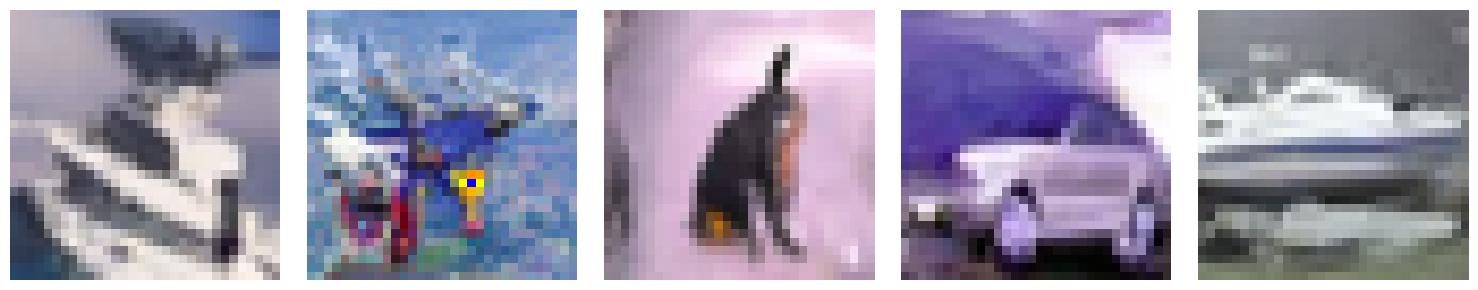

In [38]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(generated_images), figsize=(15, 3))
for ax, img in zip(axes, generated_images):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.savefig("ddim_yelp_top5.png")
plt.show()


In [3]:
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.inception import InceptionScore
from torchvision.utils import save_image
from PIL import Image
import torch
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

def load_images_from_dir(directory, max_imgs=100):
    imgs = []
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        transforms.ToTensor()
    ])
    for fname in os.listdir(directory)[:max_imgs]:
        path = os.path.join(directory, fname)
        if not os.path.isfile(path):
            continue
        img = Image.open(path).convert("RGB")
        img_tensor = transform(img)
        img_tensor = (img_tensor * 255).clamp(0, 255).byte()  # Convert to uint8
        imgs.append(img_tensor)
    return torch.stack(imgs)


gen_imgs = load_images_from_dir("ddim_yelp_generated").to(device)
real_imgs = load_images_from_dir("yelp_images/food").to(device)

# Inception Score
is_metric = InceptionScore().to(device)
is_metric.update(gen_imgs.to(device))
is_score = is_metric.compute()
print("Inception Score:", is_score)



# FID Score
fid = FrechetInceptionDistance(feature=2048).to(device)
fid.update(gen_imgs, real=False)
fid.update(real_imgs, real=True)
fid_score = fid.compute()
print("FID Score:", fid_score)


/usr/local/lib/python3.11/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


Inception Score: (tensor(1., device='cuda:0'), tensor(0., device='cuda:0'))
FID Score: tensor(530.4937, device='cuda:0')


In [56]:
import json
import os
import shutil

# Paths
PHOTO_JSON = "photos.json"  # Adjust if your file is named differently
SOURCE_IMG_DIR = "./"  # Folder where all original images are
DEST_IMG_DIR = "yelp_images/food"

# Create destination directory if it doesn't exist
os.makedirs(DEST_IMG_DIR, exist_ok=True)

# Step 1: Load photo metadata and filter by label
with open(PHOTO_JSON, "r") as f:
    photos = [json.loads(line) for line in f]

food_ids = {p["photo_id"] for p in photos if p.get("label") == "food"}
print(f"Found {len(food_ids)} food-labeled images.")

# Step 2: Copy matching images
copied = 0
for fname in os.listdir(SOURCE_IMG_DIR):
    # Check if filename (without extension) matches a food photo_id
    name, ext = os.path.splitext(fname)
    if name in food_ids:
        src_path = os.path.join(SOURCE_IMG_DIR, fname)
        dst_path = os.path.join(DEST_IMG_DIR, fname)
        shutil.copy(src_path, dst_path)
        copied += 1
    if copied >= 1000:  # Optional: cap to 1000 images
        break

print(f"Copied {copied} food images to {DEST_IMG_DIR}")


Found 108152 food-labeled images.
Copied 29 food images to yelp_images/food


**Prompt**:
1.   **Prompt** **1** :DDIM
     generate 5 + images
     Save and organise the generated image for evaluation
2.   **Prompt** **2**: ValueError: Expecting image as torch.Tensor with  dtype=torch.uint8
